## Задача


\begin{cases}
\dfrac{dx}{dt} = x \left( 1 - 0.5x - \dfrac{2}{7} \alpha_2^{-2} y \right), \quad x(0) = x_0, \\[10pt]
\dfrac{dy}{dt} = y \left( 2\alpha_2 - 0.5y - 3.5\alpha_2^2 x \right), \quad y(0) = y_0, \\[10pt]
\dfrac{d\alpha_2}{dt} = \varepsilon (2 - 7\alpha_2 x), \quad \alpha_2(0) = \alpha_{20}; \quad t \in [0; T_k].
\end{cases}

#### Рекомендуемые значения начальных данных


$0 \le x_0 \le 3$,

 $0 \le y_0 \le 15$
 
 $\alpha_{20}$ близко к нулю, например,
можно положить $\alpha_{20} = 0.0001$;

 $T_k = 1500$. 
 
$\varepsilon \le 0.01$ 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

In [ ]:
def system_func(t, v, epsilon=0.01):
    x, y, a2 = v
    a2_reg = a2 if abs(a2) > 1e-10 else 1e-10
    
    dxdt = x * (1 - 0.5 * x - (2/7) * (a2_reg**-2) * y)
    dydt = y * (2 * a2 - 0.5 * y - 3.5 * (a2_reg**2) * x)
    da2dt = epsilon * (2 - 7 * a2 * x)
    
    return np.array([dxdt, dydt, da2dt])

In [ ]:
def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h/2 * k1)
    k3 = f(t + h/2, y + h/2 * k2)
    k4 = f(t + h, y + h * k3)
    return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)

def euler_explicit(f, y0, t_span, h):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(len(t)-1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

def implicit_euler(f, y0, t_span, h, tol=1e-7, max_iter=20):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(len(t)-1):
        y_guess = y[i] + h * f(t[i], y[i])
        for _ in range(max_iter):
            y_new = y[i] + h * f(t[i+1], y_guess)
            if np.linalg.norm(y_new - y_guess) < tol: break
            y_guess = y_new
        y[i+1] = y_new
    return t, y

def modified_euler(f, y0, t_span, h):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(len(t)-1):
        k1 = f(t[i], y[i])
        k2 = f(t[i+1], y[i] + h * k1)
        y[i+1] = y[i] + (h/2) * (k1 + k2)
    return t, y

def adams_bashforth_4(f, y0, t_span, h):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(3):
        y[i+1] = rk4_step(f, t[i], y[i], h)
    
    f_vals = [f(t[i], y[i]) for i in range(4)]
    for i in range(3, len(t)-1):
        y[i+1] = y[i] + h/24 * (55*f_vals[3] - 59*f_vals[2] + 37*f_vals[1] - 9*f_vals[0])
        f_vals.pop(0)
        f_vals.append(f(t[i+1], y[i+1]))
    return t, y

def gear_4(f, y0, t_span, h, tol=1e-7):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(3): y[i+1] = rk4_step(f, t[i], y[i], h)
    
    for i in range(3, len(t)-1):
        # Начальное приближение (предиктор)
        y_guess = y[i] + h * f(t[i], y[i])
        for _ in range(20):
            y_new = (48/25)*y[i] - (36/25)*y[i-1] + (16/25)*y[i-2] - (3/25)*y[i-3] + (12/25)*h*f(t[i+1], y_guess)
            if np.linalg.norm(y_new - y_guess) < tol: break
            y_guess = y_new
        y[i+1] = y_new
    return t, y

In [ ]:
def compute_convergence_orders(methods, system_func, y0, t_span, h_start, n_refinements, ethalon_sol=None):
    """
    methods: словарь { "Имя метода": функция_метода }
    n_refinements: сколько раз уменьшать шаг в 2 раза
    ethalon_sol: если None, считается по правилу Рунге. Если передана функция, то по ней.
    """
    data = []
    prev_results = {name: None for name in methods}
    
    h = h_start
    for i in range(n_refinements):
        row = {'h': h}
        t_eval = np.arange(t_span[0], t_span[1] + h, h)
        
        for name, method_func in methods.items():
            t_curr, y_curr = method_func(system_func, y0, t_span, h)
            
            if ethalon_sol is not None:
                y_true = ethalon_sol(t_curr)
                error = np.max(np.abs(y_curr - y_true))
            else:
                if prev_results[name] is not None:
                    error = np.max(np.abs(y_curr[::2] - prev_results[name]))
                else:
                    error = np.nan
            
            row[name] = error
            prev_results[name] = y_curr
            
            p_key = f"p_{name}"
            if i > 0 and not np.isnan(data[i-1][name]) and error > 0:
                order = np.log2(data[i-1][name] / error)
                row[p_key] = round(order, 2)
            else:
                row[p_key] = np.nan
                
        data.append(row)
        h /= 2
        
    return pd.DataFrame(data)

In [ ]:
y0_system = [1.5, 7.5, 0.01]
t_range = [0, 0.01]
eps_param = 0.01

pure_system = lambda t, v: system_func(t, v, eps_param)
sol = solve_ivp(pure_system, t_range, y0_system, method='BDF', atol=1e-12, rtol=1e-12)
ethalon_func = interp1d(sol.t, sol.y, axis=1, kind='cubic', fill_value="extrapolate")

my_methods = {
    "Euler": euler_explicit,
    "ModEuler": modified_euler,
    "Adams4": adams_bashforth_4,
    "Gear4": gear_4
}

df_results = compute_convergence_orders(
    my_methods, 
    pure_system, 
    y0_system, 
    t_range, 
    h_start=0.0001, 
    n_refinements=5, 
    ethalon_sol=lambda t: ethalon_func(t).T
)

df_results

C:\Users\kaduk\AppData\Local\Temp\ipykernel_14684\1947578100.py:7: RuntimeWarning: overflow encountered in scalar multiply
  dydt = y * (2 * a2 - 0.5 * y - 3.5 * (a2_reg**2) * x)
C:\Users\kaduk\AppData\Local\Temp\ipykernel_14684\1947578100.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  dydt = y * (2 * a2 - 0.5 * y - 3.5 * (a2_reg**2) * x)
C:\Users\kaduk\AppData\Local\Temp\ipykernel_14684\1947578100.py:7: RuntimeWarning: overflow encountered in scalar power
  dydt = y * (2 * a2 - 0.5 * y - 3.5 * (a2_reg**2) * x)
C:\Users\kaduk\AppData\Local\Temp\ipykernel_14684\1947578100.py:6: RuntimeWarning: invalid value encountered in scalar multiply
  dxdt = x * (1 - 0.5 * x - (2/7) * (a2_reg**-2) * y)
C:\Users\kaduk\AppData\Local\Temp\ipykernel_14684\1947578100.py:8: RuntimeWarning: overflow encountered in scalar multiply
  da2dt = epsilon * (2 - 7 * a2 * x)


,h,Euler,p_Euler,ModEuler,p_ModEuler,Adams4,p_Adams4,Gear4,p_Gear4
0,0.000100,656.830069,NaN,760.221388,NaN,NaN,NaN,1333.010956,NaN
1,0.000050,0.621021,10.05,0.239905,11.63,NaN,NaN,0.019189,16.08
2,0.000025,0.190469,1.71,0.040297,2.57,50695.832355,NaN,0.003554,2.43
3,0.000013,0.082926,1.20,0.008102,2.31,0.000744,26.02,0.000355,3.33
4,0.000006,0.039179,1.08,0.001823,2.15,0.000052,3.84,0.000027,3.70


In [ ]:
def analyze_system_stability(v, h, epsilon=0.01):
    """
    v: текущее состояние [x, y, a2]
    h: шаг интегрирования
    epsilon: параметр системы
    """
    x, y, a2 = v
    
    J = np.zeros((3, 3))
    
    J[0, 0] = 1 - x - (2/7) * (a2**-2) * y
    J[0, 1] = -(2/7) * (a2**-2) * x
    J[0, 2] = (4/7) * (a2**-3) * x * y
    
    J[1, 0] = -3.5 * (a2**2) * y
    J[1, 1] = 2 * a2 - y - 3.5 * (a2**2) * x
    J[1, 2] = 2 * y - 7 * a2 * x * y
    
    J[2, 0] = -7 * epsilon * a2
    J[2, 1] = 0
    J[2, 2] = -7 * epsilon * x
    
    lambdas = np.linalg.eigvals(J)
    
    print(f"--- Анализ устойчивости (h={h}) ---")
    print(f"Точка: x={x:.2f}, y={y:.2f}, a2={a2:.5f}")
    
    is_stable_overall = True
    for i, lam in enumerate(lambdas):
        z = h * lam
        stability_radius = np.abs(1 + z)
        
        status = "OK" if stability_radius <= 1 else "ВЗРЫВ (Неустойчиво)"
        if stability_radius > 1: is_stable_overall = False
        
        print(f"lambda_{i+1} = {lam:.2e} | |1 + h*lambda| = {stability_radius:.4f} -> {status}")
    
    if not is_stable_overall:
        max_h = 2.0 / np.max(np.abs(lambdas))
        print(f"СОВЕТ: Для устойчивости в этой точке шаг h должен быть меньше {max_h:.2e}")
    
    return J, lambdas

# Пример использования для твоих начальных данных
y0_initial = [1.5, 7.5, 0.0001]
analyze_system_stability(y0_initial, h=0.1)
analyze_system_stability(y0_initial, h=0.1)y0_initial = [1.5, 7.5, 0.0001]

--- Анализ устойчивости (h=0.1) ---
Точка: x=1.50, y=7.50, a2=0.00010
lambda_1 = -2.14e+08 | |1 + h*lambda| = 21428570.4576 -> ВЗРЫВ (Неустойчиво)
lambda_2 = -3.15e-01 | |1 + h*lambda| = 0.9685 -> OK
lambda_3 = -7.50e+00 | |1 + h*lambda| = 0.2500 -> OK
СОВЕТ: Для устойчивости в этой точке шаг h должен быть меньше 9.33e-09


(array([[-2.14285715e+08, -4.28571429e+07,  6.42857143e+12],
        [-2.62500000e-07, -7.49980005e+00,  1.49921250e+01],
        [-7.00000000e-06,  0.00000000e+00, -1.05000000e-01]]),
 array([-2.14285715e+08, -3.14997080e-01, -7.49980292e+00]))

Generating combined trajectory plot...


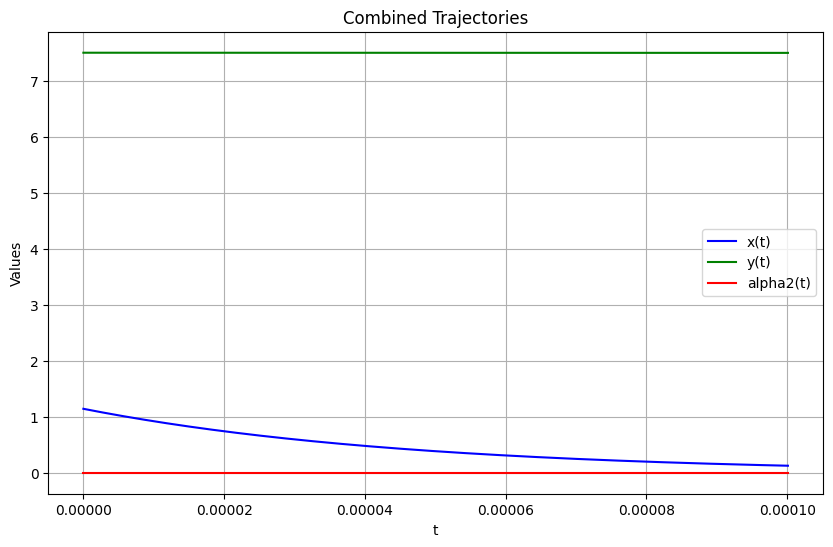

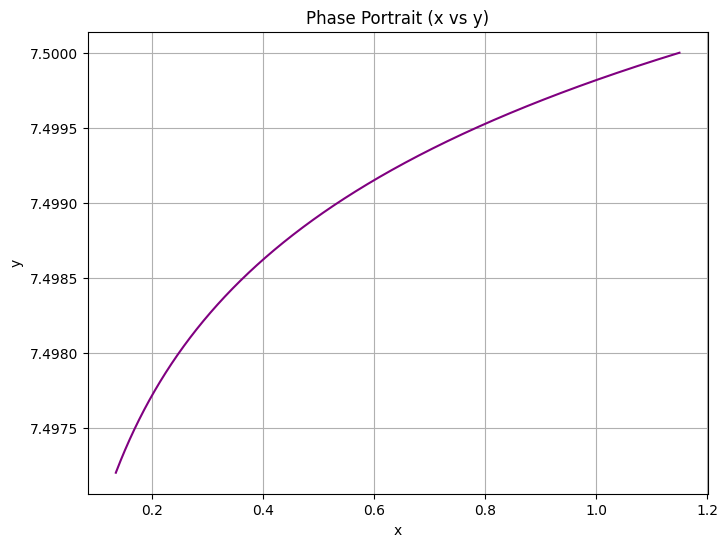

In [25]:
y0_initial = [1.15, 7.5, 0.01]
t_range_plot = [0, 0.0001]
print("Generating combined trajectory plot...")
t_plot, y_plot = gear_4(pure_system, y0_initial, t_range_plot, h=0.0000001)

plt.figure(figsize=(10, 6))
plt.plot(t_plot, y_plot[:, 0], label='x(t)', color='blue')
plt.plot(t_plot, y_plot[:, 1], label='y(t)', color='green')
plt.plot(t_plot, y_plot[:, 2], label='alpha2(t)', color='red')
plt.xlabel('t')
plt.ylabel('Values')
plt.title('Combined Trajectories')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(y_plot[:, 0], y_plot[:, 1], color='purple')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Phase Portrait (x vs y)')
plt.grid(True)
plt.show()

In [ ]:
# 4. Convergence Order Plot (Log-Log)
print("Generating convergence plot...")
plt.figure(figsize=(10, 6))
for name in my_methods.keys():
    # Filter out NaNs for plotting
    valid_mask = ~df_results[name].isna()
    plt.loglog(df_results.loc[valid_mask, 'h'], df_results.loc[valid_mask, name], 'o-', label=name)

plt.xlabel('Step size h')
plt.ylabel('Max Absolute Error')
plt.title('Convergence Order Analysis')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()